# 13.2 微调（Fine-tuning）

## 1. 核心思路（迁移学习）
将拿个在大数据集（如 ImageNet）上训练好的模型，把它迁移到你的小数据集任务上。在数据类型相差不大时，前面的特征提取层学到的特征是通用的，可以直接使用；最后的分类层需要替换成适合新任务的分类器。

步骤：
1. 加载预训练模型（保留特征提取能力）；
2. 替换最后分类层（适配新类别数）；
3. 训练时给“新分类层”更大学习率，旧层较小学习率；
4. 在目标数据集上训练。

注：pytorch更新写法差异
- 旧写法：`torchvision.models.resnet18(pretrained=True)`
- 新写法：`torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)`
- 说明：`pretrained` 参数在新版本中已不推荐使用，统一改成 `weights` 枚举。

In [1]:
%matplotlib inline
import os
import torch
import torchvision
from torch import nn
from torchvision.models import ResNet18_Weights
from d2l import torch as d2l

# %run ../my_utils.py

## 3. 数据准备（热狗 vs 非热狗）
- 用 `d2l.DATA_HUB` 注册数据集下载地址；
- `ImageFolder` 会自动按子目录名生成标签；
- `train/test` 分开管理，便于公平评估。

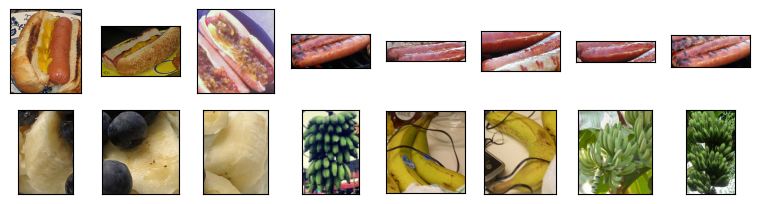

In [2]:
d2l.DATA_HUB['hotdog'] = (
    d2l.DATA_URL + 'hotdog.zip',
    'fba480ffa8aa7e0febbb511d181409f899b9baa5'
)

data_dir = d2l.download_extract('hotdog')
train_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'))
test_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'))

hotdogs = [train_imgs[i][0] for i in range(8)]
not_hotdogs = [train_imgs[-i - 1][0] for i in range(8)]
d2l.show_images(hotdogs + not_hotdogs, 2, 8, scale=1.2);

## 4. 输入预处理（训练与测试分离）
代码解释：
- 训练集：`RandomResizedCrop + RandomHorizontalFlip`，增强鲁棒性；
- 测试集：`Resize + CenterCrop`，保证评估稳定；
- `Normalize` 使用 ImageNet 统计量，和 ResNet 预训练分布对齐。

In [3]:
normalize = torchvision.transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)

train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    normalize,
])

test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize((256, 256)),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize,
])

## 5. 定义模型并替换输出层

[2026更新] 预训练模型加载：
- 2021 写法：`resnet18(pretrained=True)`
- 新版建议写法：`resnet18(weights=ResNet18_Weights.DEFAULT)`

代码解释：
- `fc.in_features` 是原全连接层输入维度；
- 新任务是二分类，所以输出改为 2；
- 新 `fc` 层是随机初始化，需要更积极地训练。

In [4]:
# [2026更新] 使用 weights 枚举代替 pretrained=True
finetune_net = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)
finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 2)
nn.init.xavier_uniform_(finetune_net.fc.weight)  # 仅重置新分类头

Parameter containing:
tensor([[ 0.0869,  0.0407, -0.0843,  ..., -0.0912, -0.0249,  0.0076],
        [ 0.1018,  0.0297,  0.1023,  ...,  0.0456, -0.0682, -0.0937]],
       requires_grad=True)

## 6. 训练函数：参数组学习率（微调常用）
代码解释（重点）：
- `params_1x`：除 `fc(full connect)` 外的参数，学习率用 `learning_rate`；
- `fc`：新加分类头，用 `10 * learning_rate`；
- 这样做的直觉：旧层已学到通用特征，轻调；新层从零开始，重调。

In [5]:
def train_fine_tuning(net, learning_rate, batch_size=128, num_epochs=5, param_group=True):
    train_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(
            os.path.join(data_dir, 'train'), transform=train_augs
        ),
        batch_size=batch_size,
        shuffle=True,
    )
    test_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(
            os.path.join(data_dir, 'test'), transform=test_augs
        ),
        batch_size=batch_size,
        shuffle=False,
    )

    devices = d2l.try_all_gpus()
    loss = nn.CrossEntropyLoss(reduction='none')

    if param_group:
        params_1x = [
            param for name, param in net.named_parameters()
            if name not in ['fc.weight', 'fc.bias']
        ]
        trainer = torch.optim.SGD(
            [
                {'params': params_1x},
                {'params': net.fc.parameters(), 'lr': learning_rate * 10},
            ],
            lr=learning_rate,
            weight_decay=1e-3,
        )
    else:
        trainer = torch.optim.SGD(
            net.parameters(), lr=learning_rate, weight_decay=1e-3
        )

    d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

## 7. 训练与对比
- 微调：小学习率 + 参数组；
- 从零训练：更大学习率，不分参数组。

loss 0.351, train acc 0.858, test acc 0.843
476.8 examples/sec on [device(type='cuda', index=0)]


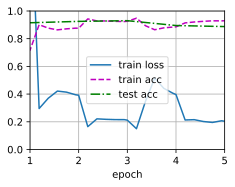

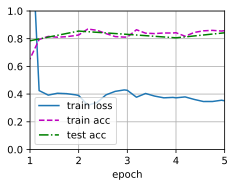

In [6]:
# 微调
train_fine_tuning(finetune_net, learning_rate=5e-5, param_group=True)

# 对比：从零训练
scratch_net = torchvision.models.resnet18(weights=None)  # [2026更新] 显式声明不加载预训练
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 2)
train_fine_tuning(scratch_net, learning_rate=5e-4, param_group=False)